In [1]:
from topological_insulator import Problem

In [2]:
structure_path = "../../../../../topological_insulator/data/structures/"
structure_name = "kagome.json"

In [3]:
def _set_eigenvalues(problem:Problem, Delta_SOC, t, delta, U, occupations):
    sublattice_labels = ["A", "B", "C", "D", "E", "F"]
    cell = problem.cell_parser
    g = cell.geometry
    n_subs = len(g.delta_vectors.value)
    subs = sublattice_labels[:n_subs]
    for i, label_i in enumerate(subs):
        parser = getattr(problem.cell_parser.eigenvalues, label_i).value
        # Diagonal Values
        base = i * 8
        parser["chadi_soc"][label_i]["Delta_pp"] = Delta_SOC
        parser["interaction"][label_i]["U_p"] = U
        parser["interaction"][label_i]["n_px_up"] = occupations[2+base]
        parser["interaction"][label_i]["n_px_down"] = occupations[3+base]
        parser["interaction"][label_i]["n_py_up"] = occupations[4+base]
        parser["interaction"][label_i]["n_py_down"] = occupations[5+base]
        parser["interaction"][label_i]["n_pz_up"] = occupations[6+base]
        parser["interaction"][label_i]["n_pz_down"] = occupations[7+base]
        # Off-Diagonal Values
        for label_j in subs:
            # Hoppings
            try:
                parser["nn_hopping"][label_j]["t_pp_sigma"] = t - delta
                parser["nn_hopping"][label_j]["t_pp_pi"] = t + delta
            except:
                pass

In [4]:
location = "edge"
N_r = 20

In [5]:
Delta_SOC = -5
t = -1

# Spin-Liquid Occupations

x1 = [1.        , 1.        , 0.41417955, 0.41417955, 0.48063523,
       0.48063523, 0.62201611, 0.62201611, 1.        , 1.        ,
       0.41417955, 0.41417955, 0.48063523, 0.48063523, 0.62201611,
       0.62201611, 1.        , 1.        , 0.51209366, 0.51209367,
       0.3828589 , 0.38285891, 0.62128025, 0.62128024]

x2 = [1.        , 1.        , 0.41904251, 0.41904255, 0.48294694,
       0.482947  , 0.62099243, 0.62099234, 1.        , 1.        ,
       0.41904251, 0.41904255, 0.48294694, 0.482947  , 0.62099243,
       0.62099234, 1.        , 1.        , 0.50996218, 0.50996231,
       0.38906916, 0.38906922, 0.61818858, 0.61818846]

x3 = [1.        , 1.        , 0.58432352, 0.58432353, 0.63572526,
       0.63572528, 0.70758527, 0.70758523, 1.        , 1.        ,
       0.58432352, 0.58432353, 0.63572526, 0.63572528, 0.70758527,
       0.70758523, 1.        , 1.        , 0.66043496, 0.66043498,
       0.55902076, 0.55902078, 0.70698765, 0.70698761]

x4 = [1.        , 1.        , 0.45220403, 0.45220409, 0.50088856,
       0.50088864, 0.5638325 , 0.56383234, 1.        , 1.        ,
       0.45220403, 0.45220409, 0.50088856, 0.50088864, 0.5638325 ,
       0.56383234, 1.        , 1.        , 0.52424108, 0.52424116,
       0.4302341 , 0.43023416, 0.56376297, 0.56376282]

cases = {
    0: {"delta": 0.832, "U": 1, "x":x1}, # mu = 4.39
    1: {"delta": 0.832, "U": 3, "x":x2}, # mu = 5.593
#     2: {"delta": 0.25, "U": 0.6, "x": x3}, # mu = 5.06
#     3: {"delta": 0.25, "U": 1, "x": x4} # mu = 4.49
}

In [6]:
results = {}
for n, U_dict in enumerate(cases.values()):
    delta = U_dict["delta"]
    U = U_dict["U"]
    x = U_dict["x"]
    print("")
    print(f"Running case for: delta/t_1 = {delta/t}, and U/t = {U/t}")
    problem = Problem(structure_path=structure_path, structure_name=structure_name)
    _set_eigenvalues(problem, Delta_SOC, t, delta, U, x)
    problem.setup(
        N_r = N_r,
        N_k = 200,
        location = location,
        BZ = "reduced",
        dangling_bonds=False
    )
    problem.run(
        H_type="reciprocal"
    )
    results[n] = problem


Running case for: delta/t_1 = -0.832, and U/t = -1.0
Building Geometry...
Geometry - Done.
Building 'Edge' Hamiltonian...
'Edge' Hamiltonian - Done.
Calculating 'Edge' eigenvalues...
'Edge' Eigenvalues - Done!

Running case for: delta/t_1 = -0.832, and U/t = -3.0
Building Geometry...
Geometry - Done.
Building 'Edge' Hamiltonian...
'Edge' Hamiltonian - Done.
Calculating 'Edge' eigenvalues...
'Edge' Eigenvalues - Done!


In [16]:
import numpy as np
edge_sites = [0, 1, 2, 56, 57, 58]
j_3_2 = [i for i in range (236, 471)]
threshold = 0.17

## Case 0

In [17]:
g = results[0].geometry
tb_edge = results[0].hamiltonian[location]["tight_binding"]
invariants = results[0].hamiltonian[location]["topological_invariants"]

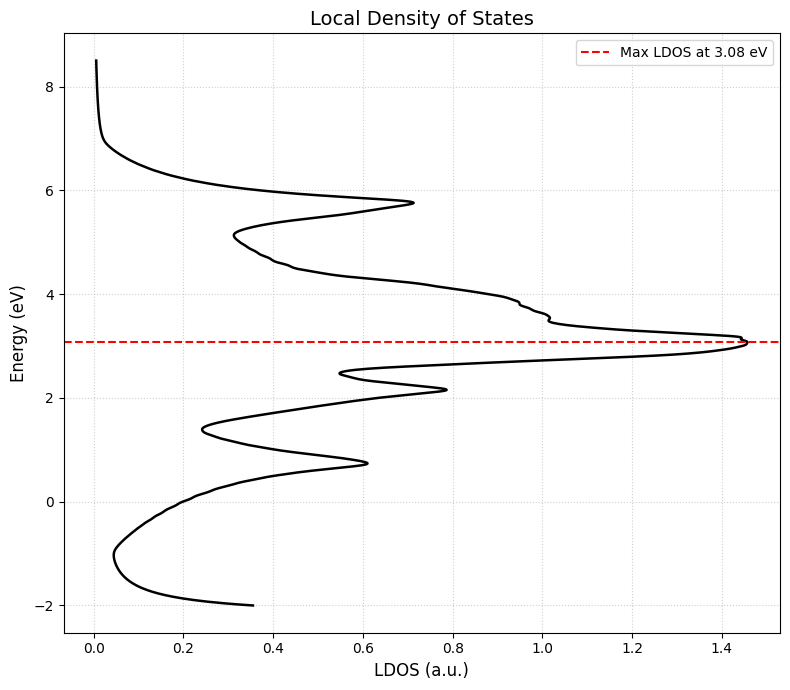

In [18]:
LDOS_0, E_0 = invariants.get_local_density_of_states(
    site_idx = 0,
    E_max = 8.5, 
    E_min = -2,
    eta = 0.08
)
invariants.plot_density_of_states(LDOS_0, E_0)

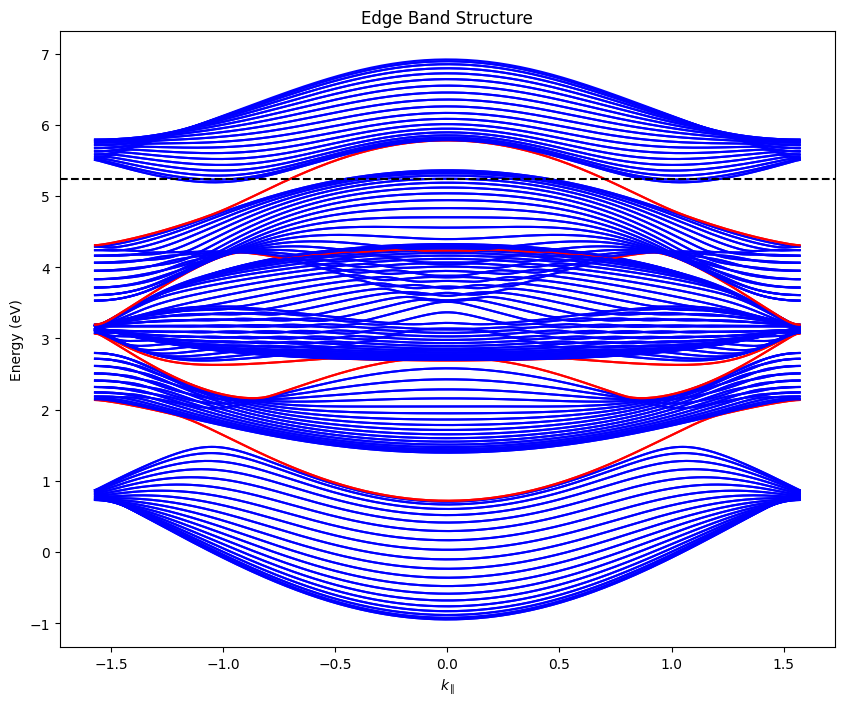

In [19]:
edge_bands_0 = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=g.k_edge[0], threshold=threshold)
edge_bands_1 = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=0.0, threshold=threshold)
edge_bands_2 = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=0.8, threshold=threshold)
edge_bands_3 = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=1.4, threshold=threshold)
edge_bands = np.unique(np.concatenate([edge_bands_0, edge_bands_1, edge_bands_2, edge_bands_3]))
tb_edge.plot_dispersion(g, j_3_2, edge_bands=edge_bands, mu = 5.24)

band idx: 274


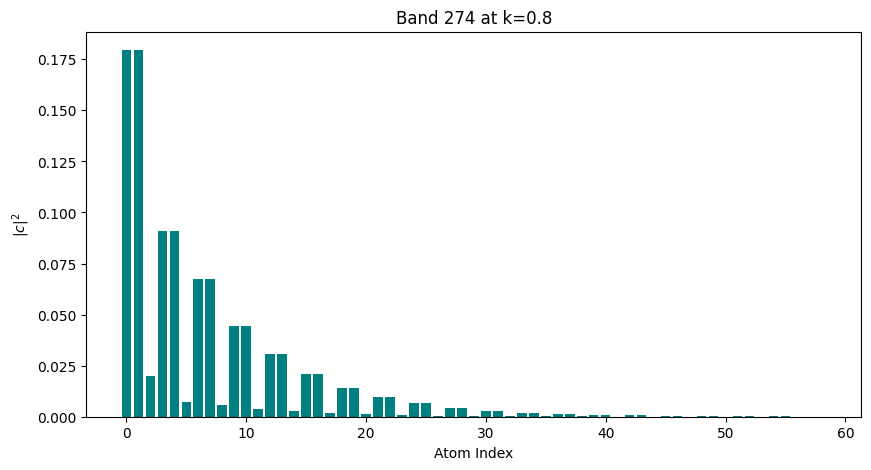

band idx: 275


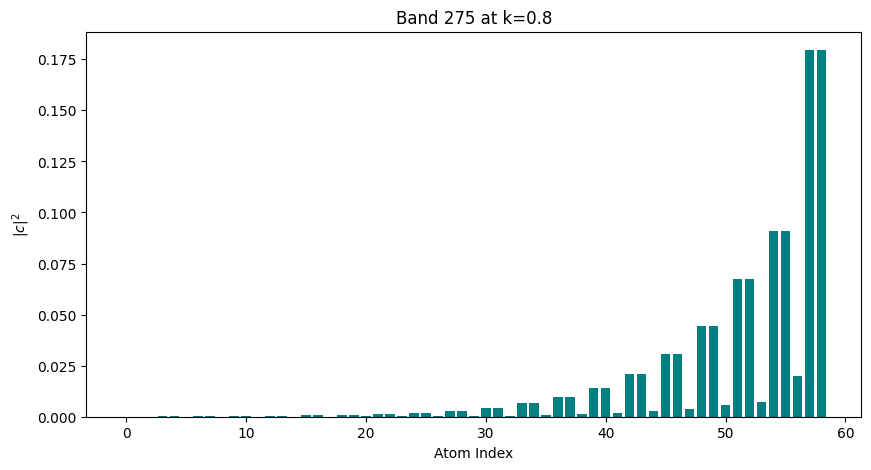

band idx: 312


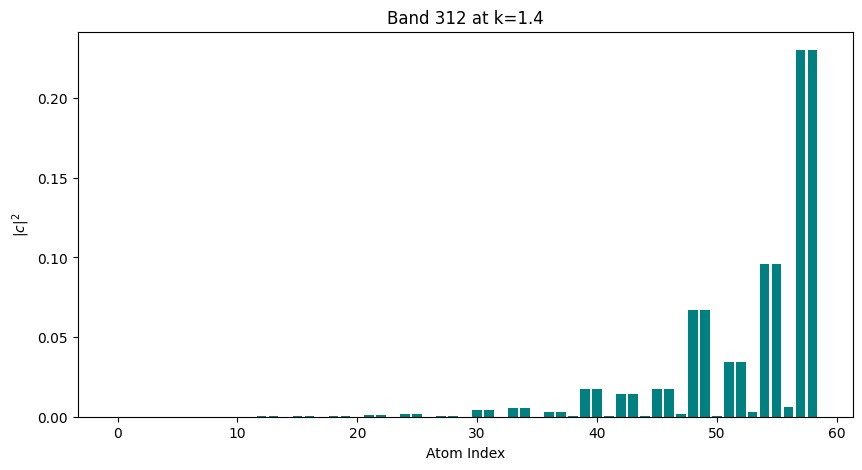

band idx: 313


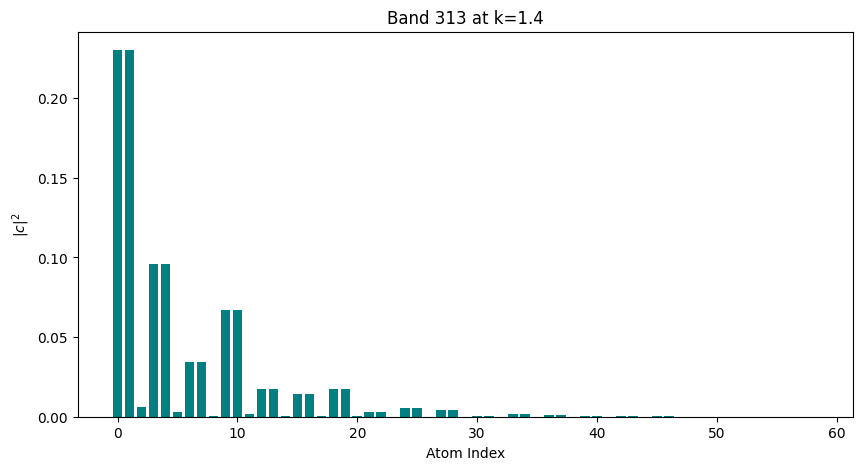

band idx: 314


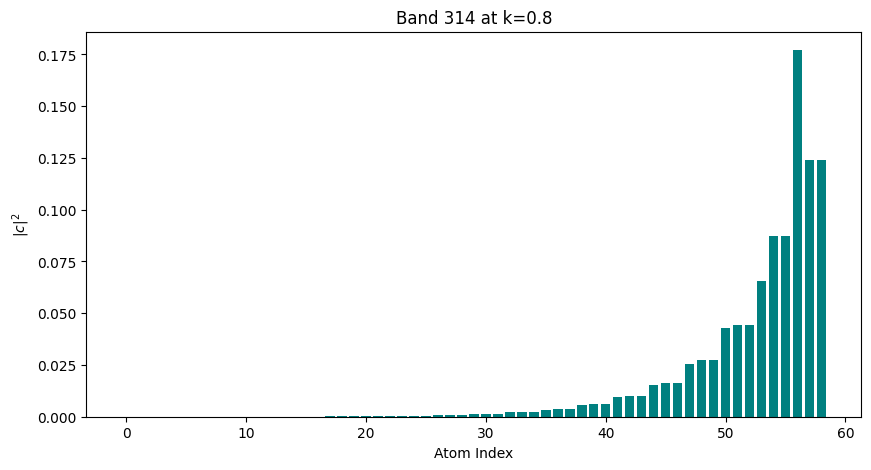

band idx: 315


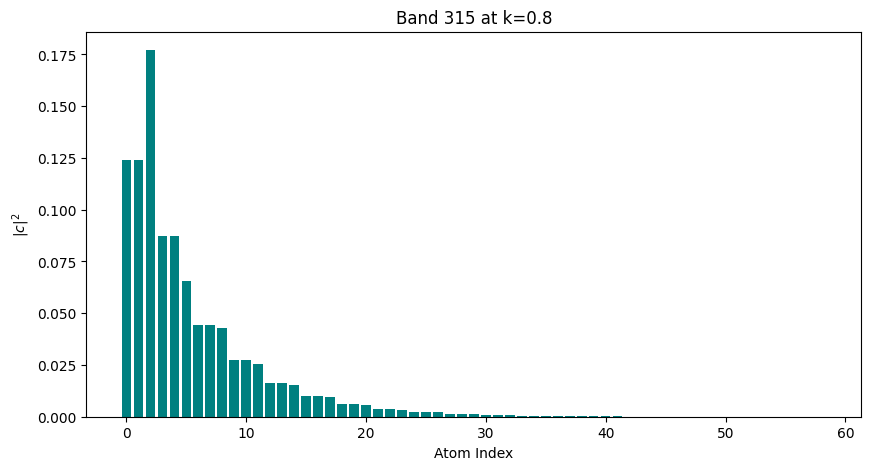

band idx: 394


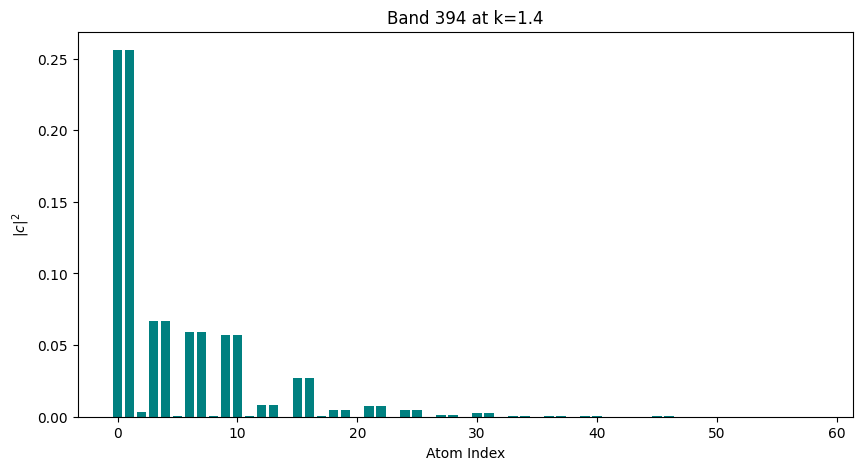

band idx: 395


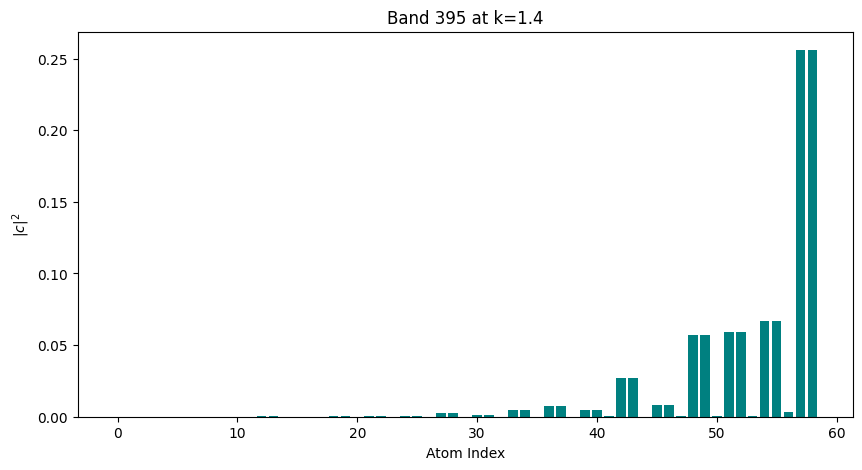

band idx: 432


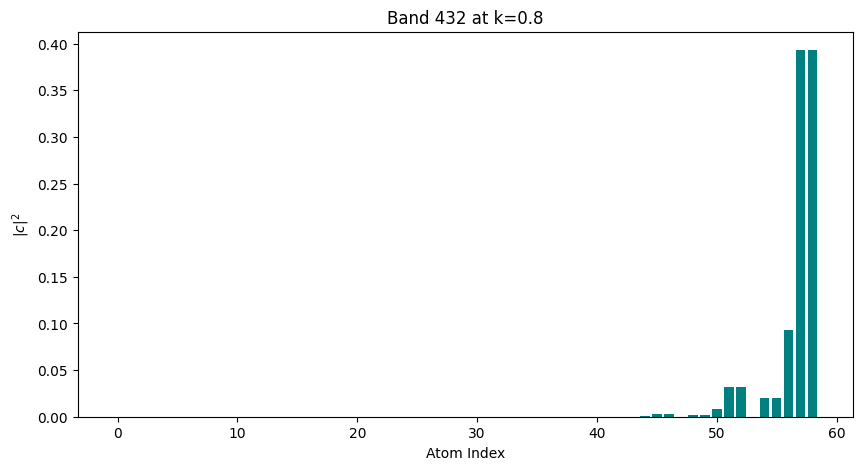

band idx: 433


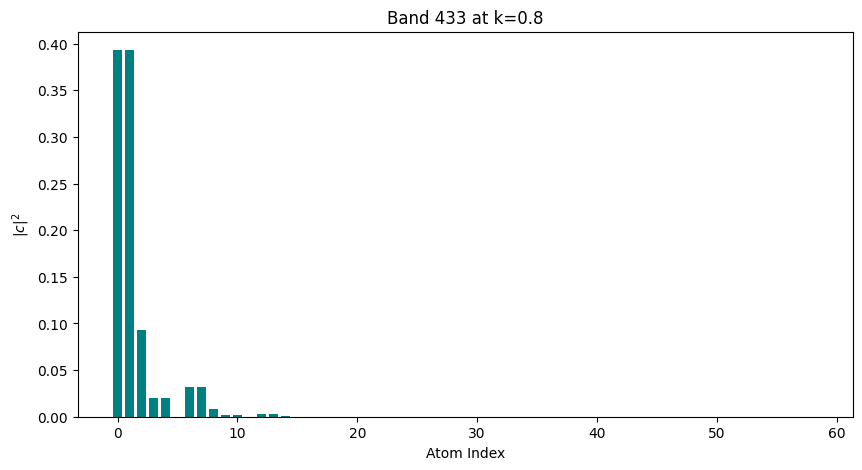

In [20]:
N_projections = len(tb_edge.coupled_states)
N_sites = len(tb_edge.sublattice_idxs)
N_bands = N_sites * N_projections

Psi_dict = tb_edge.band_structure_data["eigenvector_dict"]
for band in edge_bands:
    if band in edge_bands_0:
        k_target = g.k_edge[0]
    elif band in edge_bands_1:
        k_target = 0.0
    elif band in edge_bands_3:
        k_target = 1.4
    else:
        k_target = 0.8
    if band < min(j_3_2):
        continue
    k_idx = np.argmin(np.abs(g.k_edge - k_target))
    Psi_k = Psi_dict[band][k_idx, :]
    total_norm = np.sum(np.abs(Psi_k)**2)
    print(f"band idx: {band}")
    n_atoms = len(tb_edge.sublattice_idxs)
    atomic_wavefunctions = {}
    atom_contributions = np.zeros(n_atoms)
    for i in range(n_atoms):
        start = i * N_projections
        end = start + N_projections
        orbital_block = Psi_k[start:end]  # Orbitals for atom i
        atom_contributions[i] = np.sum(np.abs(orbital_block)**2)
        atomic_wavefunctions[i] = Psi_k[start:end] 

    from matplotlib import pyplot as plt
    plt.figure(figsize=(10, 5))
    plt.bar(range(n_atoms), atom_contributions, color='teal')
    plt.xlabel("Atom Index")
    plt.ylabel(f"$|c|^2$")
    # plt.xlim(0, 10)
    plt.title(f"Band {band} at k={np.abs(g.k_edge[k_idx]):.1f}")
    plt.show()

In [21]:
g = results[1].geometry
tb_edge = results[1].hamiltonian[location]["tight_binding"]
invariants = results[1].hamiltonian[location]["topological_invariants"]

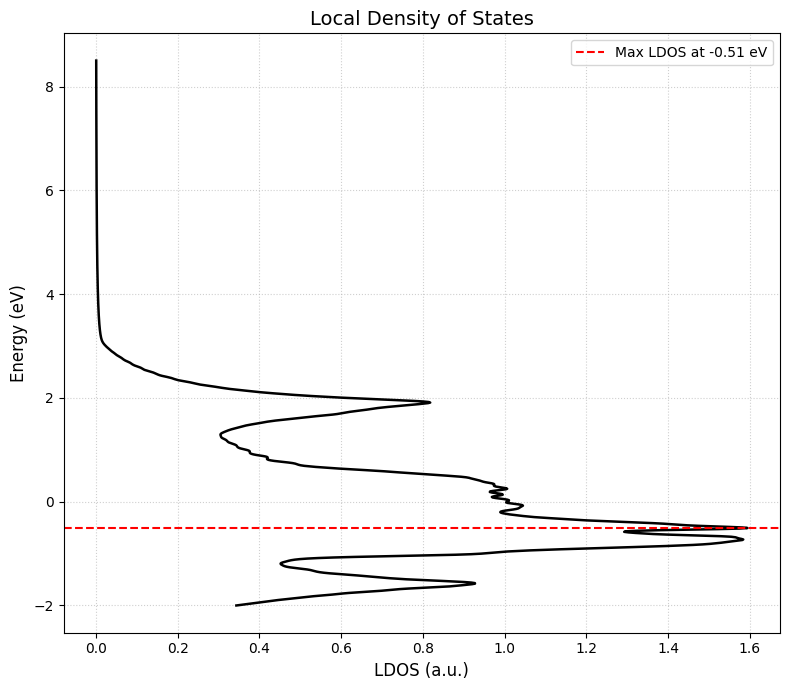

In [22]:
LDOS_0, E_0 = invariants.get_local_density_of_states(
    site_idx = 0,
    E_max = 8.5, 
    E_min = -2,
    eta = 0.05
)
invariants.plot_density_of_states(LDOS_0, E_0)

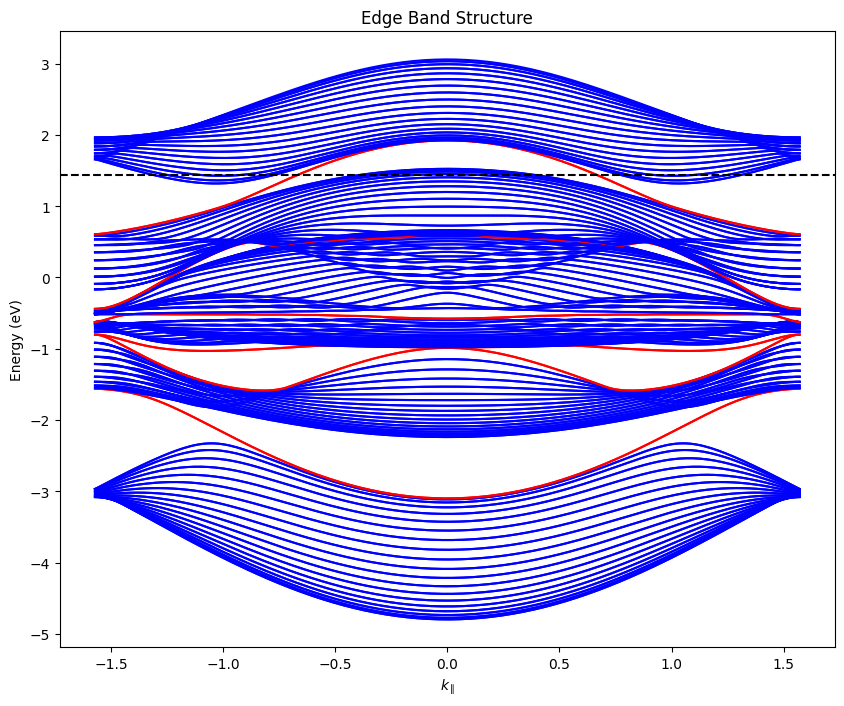

In [23]:
edge_bands_0 = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=g.k_edge[0], threshold=threshold)
edge_bands_1 = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=0.0, threshold=threshold)
edge_bands_2 = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=0.8, threshold=threshold)
edge_bands_3 = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=1.4, threshold=threshold)
edge_bands = np.unique(np.concatenate([edge_bands_0, edge_bands_1, edge_bands_2, edge_bands_3]))
tb_edge.plot_dispersion(g, j_3_2, edge_bands=edge_bands, mu= 1.44)

band idx: 274


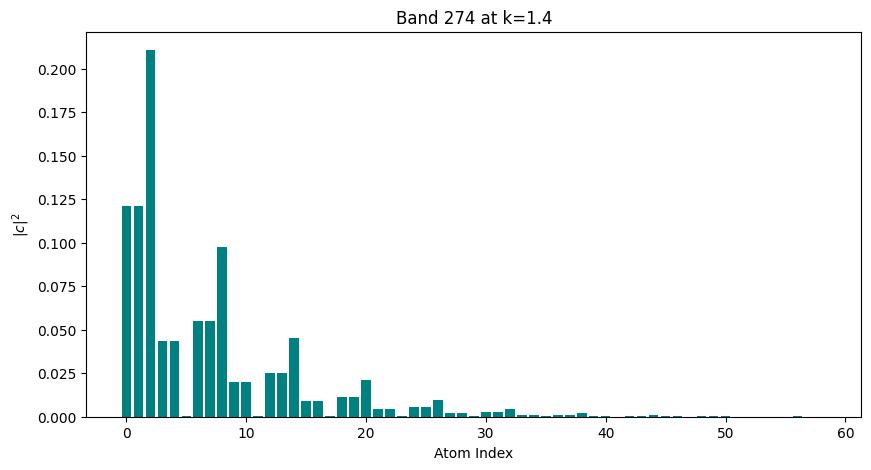

band idx: 275


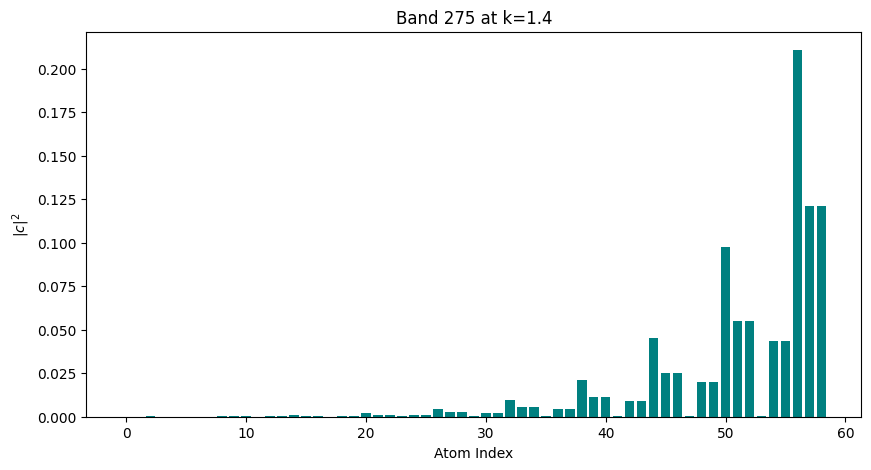

band idx: 312


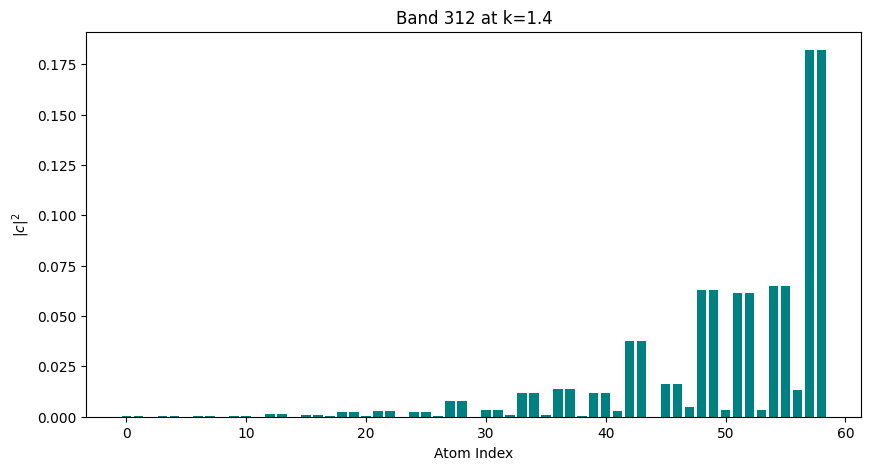

band idx: 313


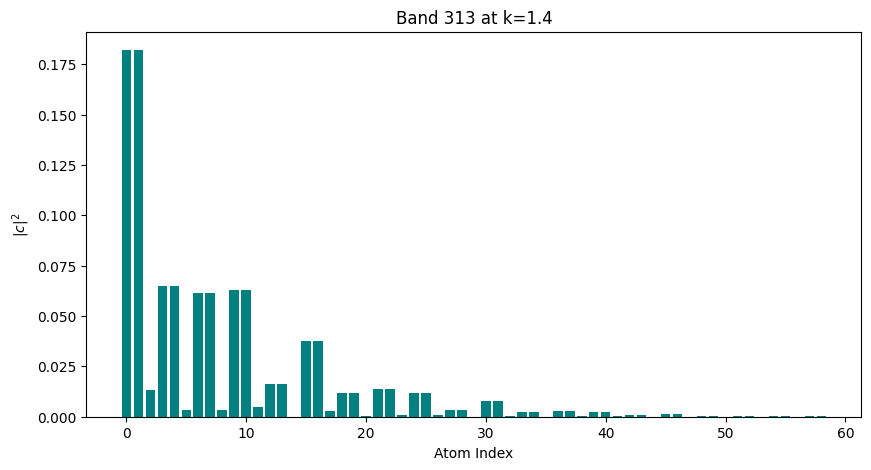

band idx: 314


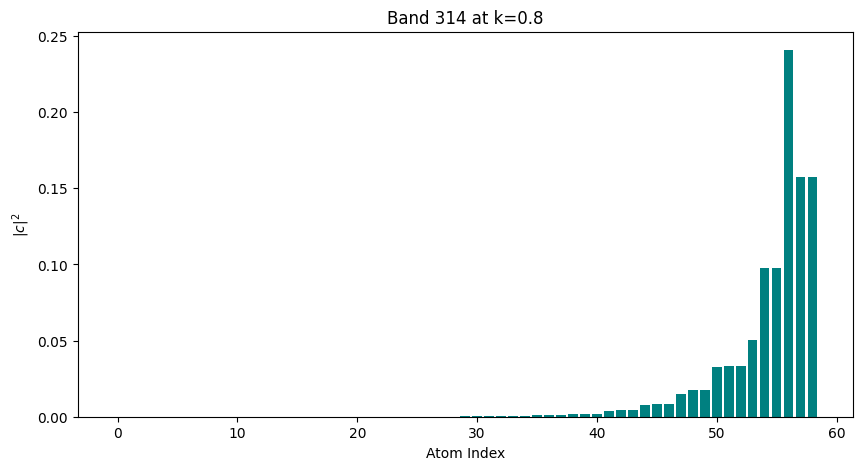

band idx: 315


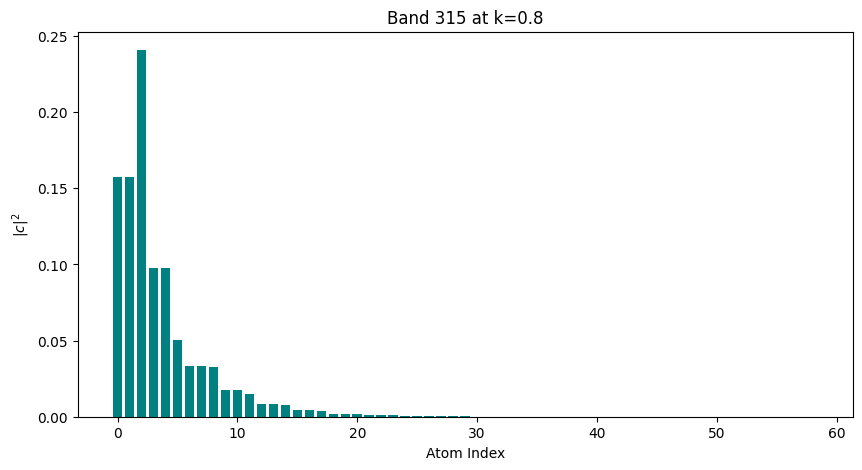

band idx: 352


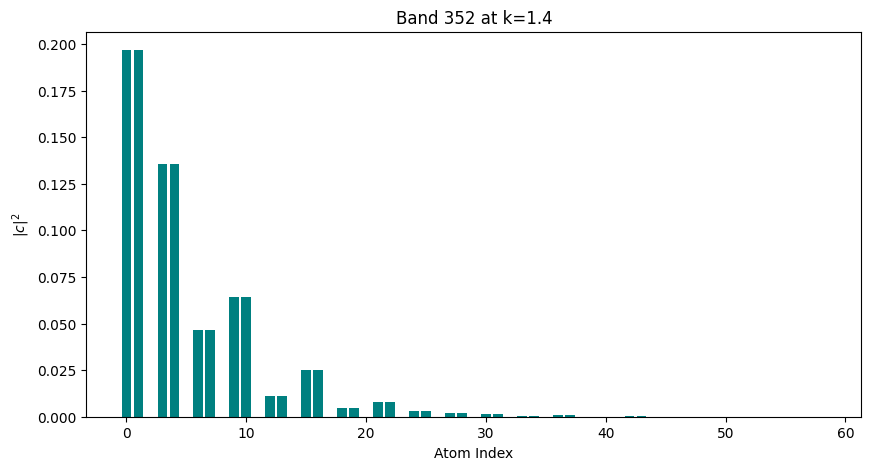

band idx: 353


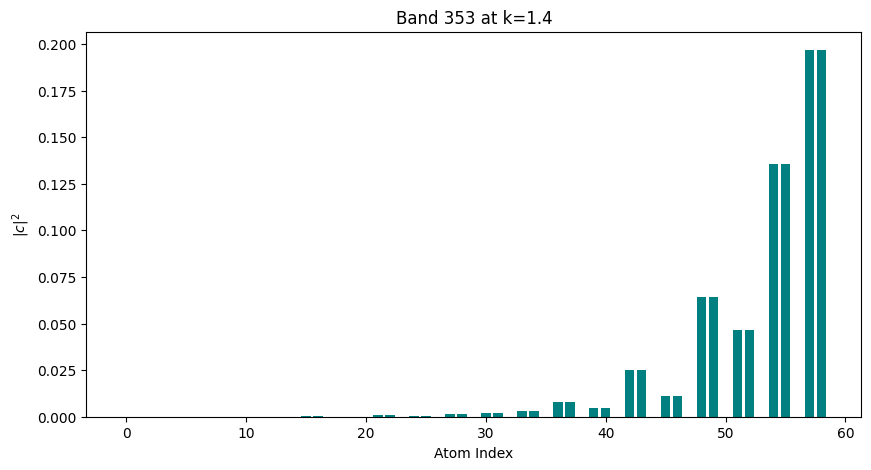

band idx: 394


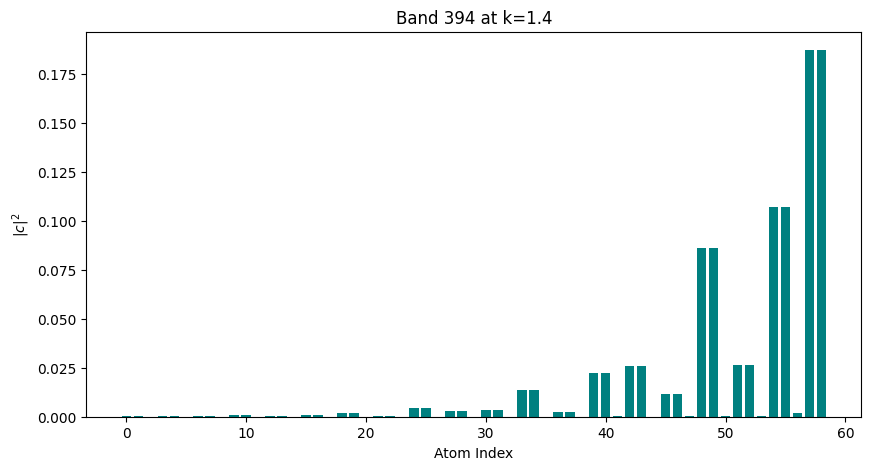

band idx: 395


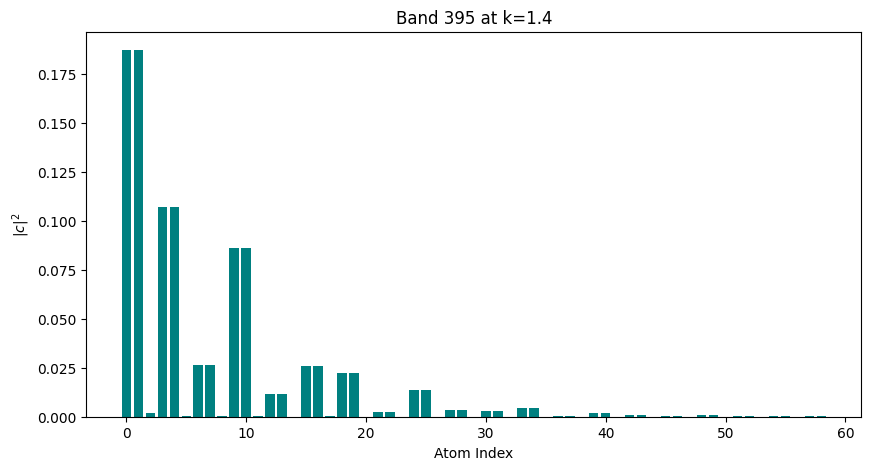

band idx: 432


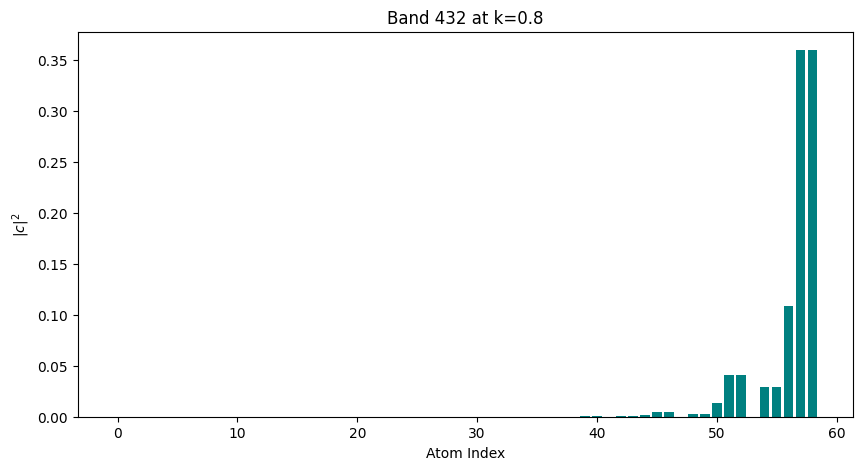

band idx: 433


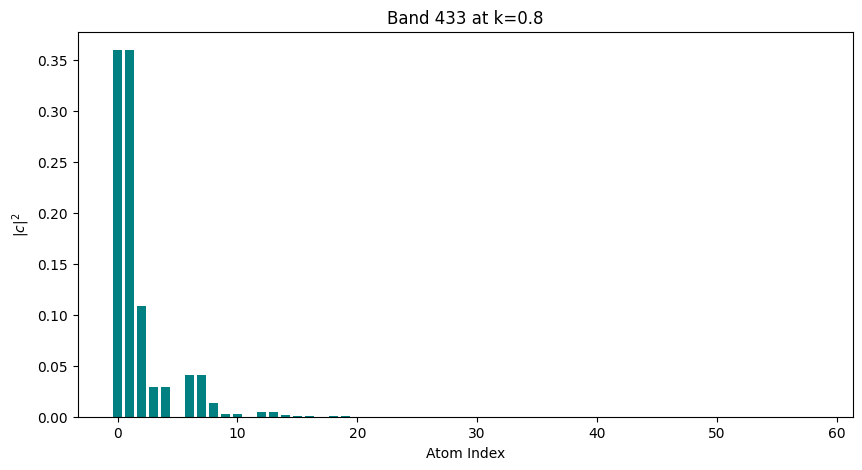

In [24]:
N_projections = len(tb_edge.coupled_states)
N_sites = len(tb_edge.sublattice_idxs)
N_bands = N_sites * N_projections

Psi_dict = tb_edge.band_structure_data["eigenvector_dict"]
for band in edge_bands:
    if band in edge_bands_0:
        k_target = g.k_edge[0]
    elif band in edge_bands_1:
        k_target = 0.0
    elif band in edge_bands_3:
        k_target = 1.4
    else:
        k_target = 0.8
    if band < min(j_3_2):
        continue
    k_idx = np.argmin(np.abs(g.k_edge - k_target))
    Psi_k = Psi_dict[band][k_idx, :]
    total_norm = np.sum(np.abs(Psi_k)**2)
    print(f"band idx: {band}")
    n_atoms = len(tb_edge.sublattice_idxs)
    atomic_wavefunctions = {}
    atom_contributions = np.zeros(n_atoms)
    for i in range(n_atoms):
        start = i * N_projections
        end = start + N_projections
        orbital_block = Psi_k[start:end]  # Orbitals for atom i
        atom_contributions[i] = np.sum(np.abs(orbital_block)**2)
        atomic_wavefunctions[i] = Psi_k[start:end] 

    from matplotlib import pyplot as plt
    plt.figure(figsize=(10, 5))
    plt.bar(range(n_atoms), atom_contributions, color='teal')
    plt.xlabel("Atom Index")
    plt.ylabel(f"$|c|^2$")
    # plt.xlim(0, 10)
    plt.title(f"Band {band} at k={np.abs(g.k_edge[k_idx]):.1f}")
    plt.show()